# Tema 3 – Ejercicios con SymPy

## Topic 3 – Practice with SymPy

**ES** Cuaderno de práctica: integra, resuelve EDO y calcula áreas rellenando las celdas de código.  
**EN** Practice notebook: integrate, solve ODEs and compute areas by filling in the code cells.

---

Primero, ejecuta esta celda de importación en tu entorno.


In [2]:
import sympy as sp
from sympy import symbols, integrate, diff, simplify, sqrt, sin, cos, log, pi, oo
from sympy.abc import x

sp.init_printing()

## 1. Primitivas / Primitives

### Ejercicio 1.1 – Primitiva polinómica / Polynomial primitive

**ES** Calcula simbólicamente la primitiva de la función

$$
f(x) = a x^2 + b x + c
$$

usando `integrate`.

**EN** Compute symbolically the primitive of

$$
f(x) = a x^2 + b x + c
$$

using `integrate`.

_Escribe tu código en la celda siguiente / Write your code in the next cell._


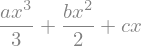

In [3]:
# Ejercicio 1.1
# TODO: define symbols a, b, c, x and compute the primitive of f(x) = a*x**2 + b*x + c

a, b, c, x = symbols("a b c x")

f = a * x**2 + b * x + c
primitive = integrate(f, x)
primitive

### Ejercicio 1.2 – Verificar primitivas / Verify primitives

    **ES** Verifica derivando que cada una de estas expresiones es una primitiva correcta:

1.  $$
    \int \cos(\ln x)\,dx = \frac{x\sin(\ln x)}{2} + \frac{x\cos(\ln x)}{2} + C
    $$

2.  $$
    \int (x+5)\cos x\,dx = x\sin x + 5\sin x + \cos x + C
    $$

3.  $$
    \int \frac{\cos(2x)}{\sin^3(2x)}\,dx = -\frac{1}{4\sin^2(2x)} + C
    $$

4.  $$
    \int \frac{1+x}{1+\sqrt{x}}\,dx =
              \frac{2x^{3/2}}{3} + 4\sqrt{x} - x - 4\ln(\sqrt{x} + 1) + C
    $$

**EN** Check by differentiating that each of these is a correct primitive.

_Idea: deriva el lado derecho y simplifica / differentiate the RHS and simplify._


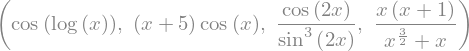

In [4]:
# Ejercicio 1.2

x = symbols("x", positive=True)

F1 = x * sin(log(x)) / 2 + x * cos(log(x)) / 2
F2 = x * sin(x) + 5 * sin(x) + cos(x)
F3 = -1 / (4 * sin(2 * x) ** 2)
F4 = 2 * x ** sp.Rational(3, 2) / 3 + 4 * sqrt(x) - x - 4 * log(sqrt(x) + 1)

check_1 = simplify(diff(F1, x))
check_2 = simplify(diff(F2, x))
check_3 = sp.trigsimp(simplify(diff(F3, x)))
check_4 = simplify(diff(F4, x))

check_1, check_2, check_3, check_4

## 2. Ecuaciones diferenciales / Differential Equations

### Ejercicio 2.1 – EDO básica / Basic ODE

**ES** Resuelve la ecuación diferencial usando `dsolve`:

$$
y' = 6x^2 - 3x^2 y.
$$

**EN** Solve the differential equation using `dsolve`:

$$
y' = 6x^2 - 3x^2 y.
$$

_Escribe tu código debajo / Write your code below._


In [5]:
# Ejercicio 2.1
# Usamos sp.Function('y') para representar la función incógnita y(x)

import sympy as sp

x = sp.Symbol("x")
y = sp.Function("y")

eq = sp.Eq(y(x).diff(x), 6 * x**2 - 3 * x**2 * y(x))
sol = sp.dsolve(eq, y(x))
sol

### Ejercicio 2.2 – Verificar soluciones propuestas / Verify proposed solutions

**ES** Comprueba que las siguientes funciones son soluciones de sus EDO.

1.  $$
    (x^2+4)y' = xy,\quad y = C_1\sqrt{x^2 + 4}.
    $$

2.  $$
    xy^2 + x + (yx^2)y' = 0,\quad y = \pm\sqrt{\frac{C_1}{x^2} - 1}.
    $$

**EN** Check that the following functions solve their ODEs.

_Pista / Hint_: calcula y' con `diff` y sustituye en la ecuación.


In [6]:
# Ejercicio 2.2 (1) – empieza con una solución genérica C1*sqrt(x**2 + 4)

C1 = sp.Symbol("C1")
x = sp.Symbol("x")

y_expr_1 = C1 * sqrt(x**2 + 4)
y_prime_1 = diff(y_expr_1, x)

# Sustituye en (x**2 + 4)*y' - x*y y simplifica
expr_1 = simplify((x**2 + 4) * y_prime_1 - x * y_expr_1)

# Para la segunda EDO basta comprobar una rama; la otra (con signo -) también da 0
y_expr_2 = sqrt(C1 / x**2 - 1)
y_prime_2 = diff(y_expr_2, x)

# Sustituye en xy^2 + x + (yx^2)y' y simplifica
expr_2 = simplify(x * y_expr_2**2 + x + (y_expr_2 * x**2) * y_prime_2)

expr_1, expr_2

## 3. Integrales definidas y área / Definite integrals and area

### Ejercicio 3.1 – Integral definida simple / Simple definite integral

**ES** Calcula con SymPy:

$$
\int_0^{\pi/2} \cos(x)\,dx.
$$

**EN** Compute with SymPy:

$$
\int_0^{\pi/2} \cos(x)\,dx.
$$


In [14]:
# Ejercicio 3.1
x = symbols("x")

result = integrate(cos(x), (x, 0, pi / 2))
result

### Ejercicio 3.2 – Área de un círculo / Area of a circle

**ES** Usa SymPy para calcular el área de un círculo de radio 2 mediante la integral:

$$
A = \int_{-2}^{2} 2\sqrt{4-x^2}\,dx.
$$

**EN** Use SymPy to compute the area of a circle of radius 2 with the integral above.

_Compara con la fórmula A = πr² / Compare with A = πr²._


In [15]:
# Ejercicio 3.2
x = symbols("x")

area_circle = integrate(2 * sqrt(4 - x**2), (x, -2, 2))
area_circle, float(area_circle)

## 4. Integrales dobles / Double integrals

### Ejercicio 4.1 – Área de un rectángulo / Rectangle area

**ES** Verifica con SymPy que:

$$
\int_a^b\int_c^d 1\,dy\,dx = (b-a)(d-c).
$$

**EN** Check with SymPy that the formula above holds.


In [16]:
# Ejercicio 4.1
from sympy.abc import a, b, c, d, x, y

I1 = integrate(1, (y, c, d))
rect_area = integrate(I1, (x, a, b))
simplify(rect_area)

### Ejercicio 4.2 – Círculo como integral doble / Circle as double integral

    **ES** Escribe en SymPy la integral doble cartesiana

$$
A = \int_{-2}^{2}\int_{-\sqrt{4-x^2}}^{\sqrt{4-x^2}} 1\,dy\,dx
$$

y comprueba que el resultado es el área del círculo de radio 2.

**EN** Write in SymPy the Cartesian double integral above and check that it gives the area of the radius–2 circle.

    _Bonus_: intenta también la versión en coordenadas polares.


In [7]:
# Ejercicio 4.2 – forma cartesiana
x, y = symbols("x y")

A_cart = integrate(integrate(1, (y, -sqrt(4 - x**2), sqrt(4 - x**2))), (x, -2, 2))
A_cart

In [18]:
# Ejercicio 4.2 – bonus: forma polar
from sympy.abc import r, theta

A_polar = integrate(integrate(r, (r, 0, 2)), (theta, 0, 2 * pi))
A_polar

## 5. Integral impropia / Improper integral

### Ejercicio 5.1 – Ejemplo típico / Typical example

**ES** Calcula con SymPy la integral impropia:

$$
\int_1^{+\infty}\frac{1}{x^2}\,dx.
$$

**EN** Compute with SymPy the improper integral above.

_Pregunta / Question_: ¿por qué converge (el resultado es finito)? / why does it converge?


In [19]:
# Ejercicio 5.1
from sympy import oo

x = symbols("x")

improper = integrate(1 / x**2, (x, 1, oo))
improper

## 6. Actividades de 15 minutos / 15-minute activities

### Actividad 6.1 / Activity 6.1 – Integral + EDO

**ES**

1. Con SymPy, comprobar que
   $$
   \int_0^{\pi} x\sin x\,dx = \pi.
   $$
2. Resolver la EDO
   $$
   y' = x y,\quad y(0)=2
   $$
   con `dsolve`.

**EN**

1. With SymPy, check that
   $$
   \int_0^{\pi} x\sin x\,dx = \pi.
   $$
2. Solve the ODE
   $$
   y' = x y,\quad y(0)=2
   $$
   with `dsolve`.

_Usa las celdas de abajo / use the cells below._


In [20]:
# Actividad 6.1 – Parte 1: integral definida
from sympy import N

x = symbols("x")

I = integrate(x * sin(x), (x, 0, pi))
I, N(I)

In [21]:
# Actividad 6.1 – Parte 2: EDO con condición inicial
import sympy as sp

x = sp.Symbol("x")
y = sp.Function("y")

ode = sp.Eq(y(x).diff(x), x * y(x))
sol_ode = sp.dsolve(ode, ics={y(0): 2})
sol_ode

### Actividad 6.2 / Activity 6.2 – Área y visualización / Area and plotting

**ES**

1. Representar f(x)=sqrt(x) y g(x)=x^2 en [0,1].
2. Comprobar que el área entre ellas es 1/3.

**EN**

1. Plot f(x)=sqrt(x) and g(x)=x^2 on [0,1].
2. Check that the area between them is 1/3.

$$
A = \int_0^1 (\sqrt{x}-x^2)\,dx = \frac{1}{3}.
$$

_Usa SymPy y, opcionalmente, matplotlib para la gráfica._ / _Use SymPy and optionally matplotlib for the plot._


In [22]:
# Actividad 6.2 – Parte 1: área con SymPy
x = symbols("x")
f = sqrt(x)
g = x**2

A = integrate(f - g, (x, 0, 1))
A

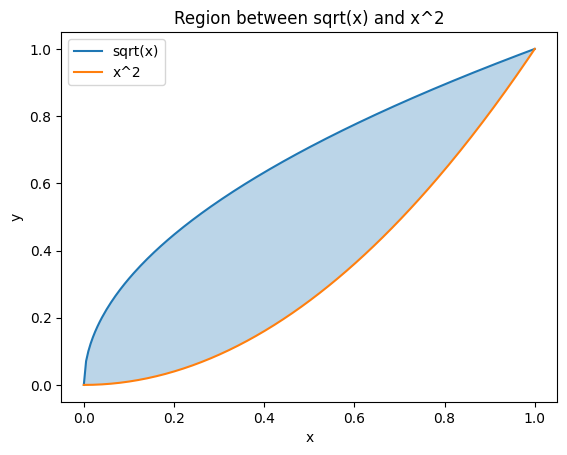

In [23]:
# Actividad 6.2 – Parte 2 (opcional): gráfica con matplotlib
import numpy as np
import matplotlib.pyplot as plt

xs = np.linspace(0, 1, 200)

# Gráfica de las dos funciones y del área entre ellas
plt.plot(xs, np.sqrt(xs), label="sqrt(x)")
plt.plot(xs, xs**2, label="x^2")
plt.fill_between(xs, np.sqrt(xs), xs**2, alpha=0.3)
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.title("Region between sqrt(x) and x^2")
plt.show()